# The experimental dataset used in this Jupyter Notebook contains a total of 8 cells: 4 in the No_Stimulation condition and 4 in the Glu (5 min) condition.

In [58]:
import sys
sys.path.append("../")
from pathlib import Path
plotDirectoryPath= Path("/home/anshu/Documents/Github_push/Output/")
from commonInput import *
from utils import *
import warnings
print("-------------------------------------------------")
print("Ground Truth MASK File List")
pprint(LabelMRCfilelist)
print("-----------------------------------------------")
print("-------------------------------------------------")
print("RAW Truth MRC File List")
pprint(RawMRCfilelist)
print("-----------------------------------------------")
print("File List")
pprint(jsonFileList)
print("-------------------------------------------------")
print("Cell Names Dictionary with Conditions as Keys")
pprint(cellNameDict)
print("-------------------------------------------------")
print("Cell Names")
pprint(cell_names)
print("-------------------------------------------------")
print("Conditions")
pprint(conditions)
print("-------------------------------------------------")

-------------------------------------------------
Ground Truth MASK File List
['/home/anshu/Documents/Github_push/Data/Stevens_pancreatic_INS_1E_783_5_pre_rec/Stevens_pancreatic_INS_1E_783_5_pre_rec_labels.mrc',
 '/home/anshu/Documents/Github_push/Data/Stevens_pancreatic_INS_1E_784_5_pre_rec/Stevens_pancreatic_INS_1E_784_5_pre_rec_labels.mrc',
 '/home/anshu/Documents/Github_push/Data/Stevens_pancreatic_INS_1E_783_6_pre_rec/Stevens_pancreatic_INS_1E_783_6_pre_rec_labels.mrc',
 '/home/anshu/Documents/Github_push/Data/Stevens_pancreatic_INS_1E_783_12_pre_rec/Stevens_pancreatic_INS_1E_783_12_pre_rec_labels.mrc',
 '/home/anshu/Documents/Github_push/Data/Stevens_PBC_INS1e_25mMglu_5min_1060_4-6_pre_rec/Stevens_PBC_INS1e_25mMglu_5min_1060_4-6_pre_rec_labels.mrc',
 '/home/anshu/Documents/Github_push/Data/Stevens_PBC_INS1e_25mMglu_5min_1092_11_pre_rec/Stevens_PBC_INS1e_25mMglu_5min_1092_11_pre_rec_labels.mrc',
 '/home/anshu/Documents/Github_push/Data/Stevens_PBC_INS1e_25mMglu_5min_1044_7_pre_rec

# Volumne and Surface Area

In [2]:
MitoVolSADF, MitoVolSAIndiDF, MitoVolSAIndiDF_Explode = labelVolumeSAvaluesParallel(label="mitochondria",filelist=jsonFileList, conditions=conditions, volSAFlag="both", collectIndividualList=True, njobs=20)
# MitoVolSADF.to_csv(os.path.join(plotDirectoryPath,'MitoVolSADF.csv'), index = False)
# MitoVolSAIndiDF_Explode.to_csv(os.path.join(plotDirectoryPath,'MitoVolSAIndiDF_Explode.csv'), index = False)

---------------------------------------------------------
2026-03-25 11:01:40.070867
---------------------------------------------------------
---------------------------------------------------------
2026-03-25 11:04:52.894779


In [3]:
MitoVolSAIndiDF_Explode = pd.read_csv(os.path.join(plotDirectoryPath,"MitoVolSAIndiDF_Explode.csv"))

,cell_id,conditions,volume_um,volume_voxels,SurfaceA_um,SurfaceArea
0,783_5,No_Stimulation,0.057643,"[1155, 490, 1189, 105, 1132, 176, 1949, 583, 1...",1.417882,"[1046, 488, 958, 176, 856, 250, 1868, 722, 216..."
0,783_5,No_Stimulation,0.024455,"[1155, 490, 1189, 105, 1132, 176, 1949, 583, 1...",0.661498,"[1046, 488, 958, 176, 856, 250, 1868, 722, 216..."
0,783_5,No_Stimulation,0.05934,"[1155, 490, 1189, 105, 1132, 176, 1949, 583, 1...",1.298596,"[1046, 488, 958, 176, 856, 250, 1868, 722, 216..."
0,783_5,No_Stimulation,0.00524,"[1155, 490, 1189, 105, 1132, 176, 1949, 583, 1...",0.238573,"[1046, 488, 958, 176, 856, 250, 1868, 722, 216..."
0,783_5,No_Stimulation,0.056495,"[1155, 490, 1189, 105, 1132, 176, 1949, 583, 1...",1.160332,"[1046, 488, 958, 176, 856, 250, 1868, 722, 216..."
...,...,...,...,...,...,...
7,1044_8-9,Glu(5min),0.004034,"[767421, 77, 6042, 1, 14101, 320, 10641, 7565,...",0.229637,"[352874, 152, 4060, 6, 9332, 414, 7510, 4198, ..."
7,1044_8-9,Glu(5min),0.032381,"[767421, 77, 6042, 1, 14101, 320, 10641, 7565,...",0.912945,"[352874, 152, 4060, 6, 9332, 414, 7510, 4198, ..."
7,1044_8-9,Glu(5min),0.021535,"[767421, 77, 6042, 1, 14101, 320, 10641, 7565,...",0.616098,"[352874, 152, 4060, 6, 9332, 414, 7510, 4198, ..."
7,1044_8-9,Glu(5min),0.231694,"[767421, 77, 6042, 1, 14101, 320, 10641, 7565,...",3.592971,"[352874, 152, 4060, 6, 9332, 414, 7510, 4198, ..."


# Volume Plot

Normality p-values: [8.407790785948902e-45, 7.006492321624085e-45]
Using Kruskal-Wallis + Dunn
Global test p: 0.0048624578173075425


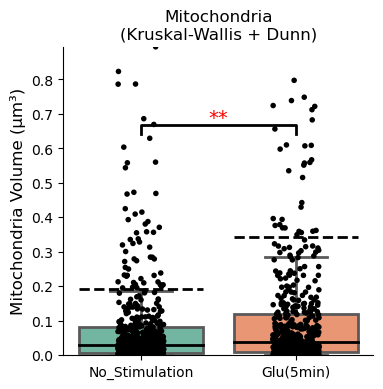

In [57]:
#This block of code plots volume and surface area measurements. Variables ending with "_um" represent values in micrometers, whereas "volume_voxels" and "SurfaceArea" represent values in voxel units.
stats,test=stats_boxplot1(

    data=MitoVolSAIndiDF_Explode,

    x="conditions",

    y="volume_um", # put y ="SurfaceA_um" for surface area plot. 

    ylabel="Mitochondria Volume (µm³)",

    title="Mitochondria",
    show_points= True,
    save_path=plotDirectoryPath
)

# Complexity Index

In [ ]:
#MCIdf = calculateMCIParallel(jsonFileList, "mitochondria", conditions,cell_IDs, njobs = 18)

# Linear Absorption Coefficient Intensity

In [ ]:
#dfLac = labelLACvaluesParallel("mitochondria",jsonFileList, conditions, collectCompleteList = True, njobs=20)

# Radial Contours

In [2]:
# size = 'global' for complete mitochondrial network, for other morphotypes use 'fragmented', 'intermediate', 'interconnected'.
LACdf, EnrichmentDF = RadialContour(jsonFileList, conditions, size = "global", df_save = False, save_edt = False) 

---------------------------------------------------------
2026-03-25 11:20:43.733609
---------------------------------------------------------
---------------------------------------------------------
2026-03-25 11:30:40.406998
---------------------------------------------------------


In [ ]:
# Enrichment Dataframe
EnrichmentDF

# Enrichment Plot

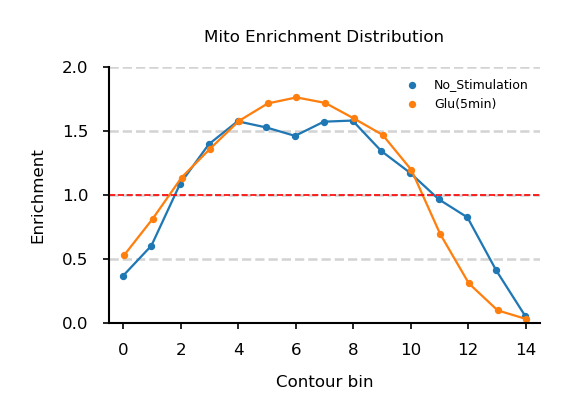

Saved figure → ./plots/Enrichment_plot.png


In [45]:
pointplot(
    data=EnrichmentDF,
    x_col="ContourBin",
    y_col="Enrichment",
    hue_col="Condition",
    conditions=["No_Stimulation","Glu(5min)"],
    filename="Enrichment_plot",
    save_path="./plots",
    ylabel="Enrichment",
    xlabel="Contour bin",
    title="Mito Enrichment Distribution"
)

# Voxel Intensity Plot

In [ ]:
# Mito Voxel Intensity Dataframe
LACdf

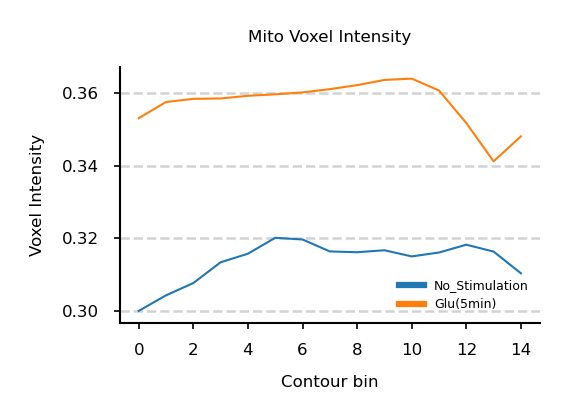

Saved figure → ./plots/Voxel Intensity.png


In [48]:
line_plot(
    data=LACdf,
    x_col="BinIndex",   
    y_col="MitoVoxelLAC", 
    hue_col="Condition",
    conditions=["No_Stimulation","Glu(5min)"],
    filename="Voxel Intensity",
    save_path="./plots",
    ylabel="Voxel Intensity",
    xlabel="Contour bin",
    title="Mito Voxel Intensity",
)

# Clustering based Analysis


Cluster counts:
cluster
0    1004
1     852
2     428
Name: count, dtype: int64


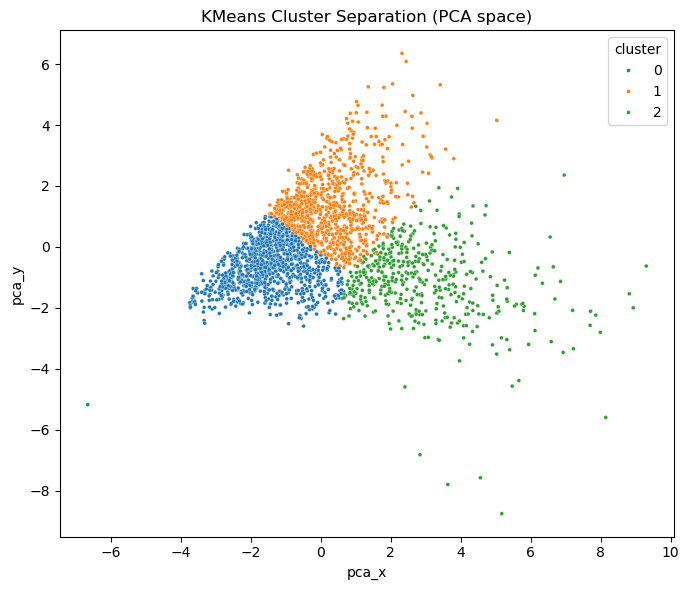

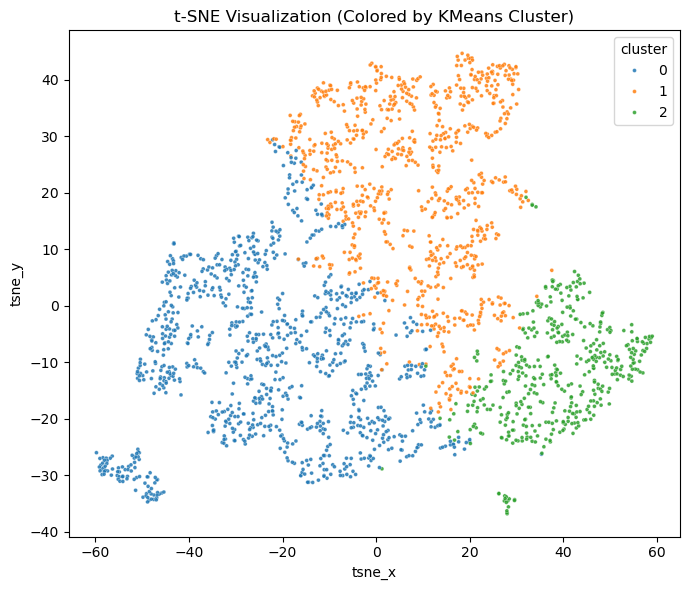

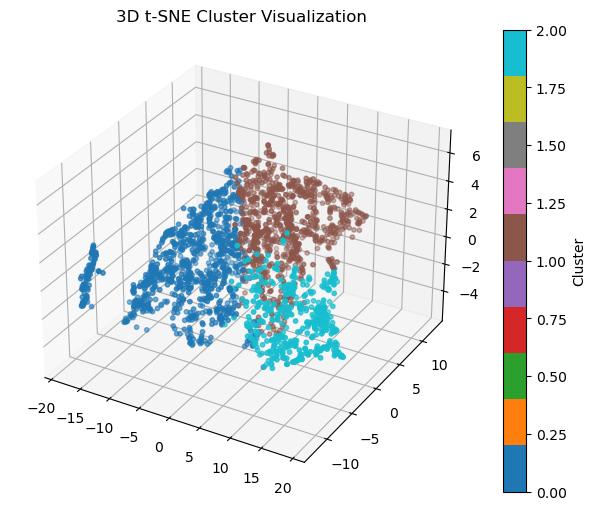

In [2]:
from read_write_mrc import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob,os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


# -----------------------------------------------------------------------------------------
# 1. Load DF  (must contain cell_id, condition, mito_id, features already from extraction)
# -----------------------------------------------------------------------------------------

df_updated = pd.read_csv('DataFrames/25Features_Medium_Mito_DF.csv')


selected_features = [
    # Size / Mass
    "volume_um",
    "convex_hull_volume_um",

    # Shape
    "sphericity",
    "aspect_ratio",
    "flatness",


    # Skeleton / Network
    "skeleton_length",
    "tortuosity",
    "fractal_dim"
]


df_f = df_updated.copy()
df_f[selected_features] = df_f[selected_features].replace([np.inf,-np.inf],np.nan).fillna(0)

conditions_dict = np.load("conditions_dict.npy", allow_pickle=True).item()
GTmaskList = sorted(glob.glob(os.path.join('Data/1_masks','*.mrc')))

# -----------------------------------------------------------------------------------------
# 2. Scale features (KMeans requires equal scale)
# -----------------------------------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_f[selected_features])

# -----------------------------------------------------------------------------------------
# 3. KMeans clustering (no PCA unless you want later)
# -----------------------------------------------------------------------------------------

k=3 # change 5-8 to improve cluster quality
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_f['cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:")
print(df_f['cluster'].value_counts())

from sklearn.decomposition import PCA

# --- PCA 2D view ---
pca_vis = PCA(n_components=2).fit_transform(X_scaled)
df_f['pca_x']=pca_vis[:,0]
df_f['pca_y']=pca_vis[:,1]

plt.figure(figsize=(7,6))
sns.scatterplot(data=df_f, x='pca_x', y='pca_y', hue='cluster', palette='tab10', s=8)
plt.title("KMeans Cluster Separation (PCA space)")
plt.tight_layout(); plt.show()

# --- t-SNE (2D) ---
perplexity = 35
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate='auto', metric='euclidean', random_state=42)
tsne_out = tsne.fit_transform(X_scaled)

df_f['tsne_x'] = tsne_out[:,0]
df_f['tsne_y'] = tsne_out[:,1]

plt.figure(figsize=(7,6))
sns.scatterplot(data=df_f,x='tsne_x',y='tsne_y',hue='cluster',palette='tab10',s=8,alpha=0.85)
plt.title("t-SNE Visualization (Colored by KMeans Cluster)")
plt.tight_layout()
plt.savefig(f"ClusterImages/tsne_{perplexity}_clusters.png", dpi=300, bbox_inches='tight')
plt.show()

# OPTIONAL — 3D t-SNE (only if needed)
from mpl_toolkits.mplot3d import Axes3D

tsne3 = TSNE(n_components=3, perplexity=perplexity, learning_rate='auto',random_state=42)
X_t3 = tsne3.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X_t3[:,0], X_t3[:,1], X_t3[:,2], c=df_f['cluster'], cmap='tab10', s=10)
ax.set_title("3D t-SNE Cluster Visualization")
fig.colorbar(p,label='Cluster')
plt.show()


# =========================================================================================
# 6. PICK representative mitochondria from each cluster (centroid + percentiles)
# =========================================================================================

# compute cluster centroids in feature space
centroids = kmeans.cluster_centers_

def extract_representatives(df_c,k):
    """ return centroid,25%,50%,75% nearest mito indices """
    reps={}
    for c in range(k):
        sub=df_c[df_c.cluster==c]

        # distance from centroid in scaled feature space
        Xc=X_scaled[sub.index]
        dist=np.linalg.norm(Xc-centroids[c],axis=1)

        sub=sub.assign(distance=dist).sort_values("distance")

        reps[c]={
            "centroid" : sub.iloc[0],
            "p25"      : sub.iloc[int(0.25*len(sub))],
            "p50"      : sub.iloc[int(0.50*len(sub))],
            "p75"      : sub.iloc[int(0.75*len(sub))]
        }
    return reps

reps=extract_representatives(df_f,k)

# =========================================================================================
# 7. Load & extract mito masks from real cells for visual validation
# =========================================================================================

import re
from mrcfile import open as mrc_open
from scipy.ndimage import label

def extract_single_mito(cell_path,mito_number):
    vol = read_mrc(cell_path).get()
    mito=(vol==5).astype(np.int8)
    structure = np.ones((3, 3, 3), dtype=np.int32)
    L, n = label(mito,structure)
    mask=(L==mito_number).astype(np.int8)
    return mask

def save_representative_mitos(reps, GTmaskList, out_dir="Mito_Cluster_Export2"):
    os.makedirs(out_dir, exist_ok=True)

    for c in reps:
        cluster_name = label_map[c] if c in label_map else f"Cluster_{c}"
        folder = os.path.join(out_dir, f"Cluster_{c}_{cluster_name}")
        os.makedirs(folder, exist_ok=True)

        for tag, key in zip(["centroid","25","50","75"],["centroid","p25","p50","p75"]):
            row = reps[c][key]

            # extract mito number
            import re
            mito_number = row["mito_id"]

            cell_id     = row["cell_id"]
            condition   = row["condition"]         # already exists in DF
            mito_name   = f"{cell_id}_mito_{mito_number}_{condition}_{tag}.mrc"

            # find respective full cell file path
            cell_path = [p for p in GTmaskList if cell_id in p][0]

            mito_mask = extract_single_mito(cell_path, mito_number)

            save_path = os.path.join(folder, mito_name)
            write_mrc(save_path, mito_mask.astype(np.int8))

            print(f"Saved: {save_path}")

    print("\n✔ Mito masks saved with full naming format\n")

# finally run:
# plot_representatives(reps,GTmaskList)   # UNCOMMENT WHEN GTmaskList is available
# save_representative_mitos(reps, GTmaskList, out_dir="ClusterImages/25Features_MediumMitoClusterImages")   # save .mrc files

In [42]:
import numpy as np
import os
from scipy.ndimage import label
from read_write_mrc import read_mrc, write_mrc


# =========================================================
# Extract mito mask safely
# =========================================================
def get_mito_mask(cell_path, mito_id):
    vol = read_mrc(cell_path).get()
    mito = (vol == 5).astype(np.int8)

    structure = np.ones((3, 3, 3), dtype=np.int32)
    L, n = label(mito, structure)

    if mito_id > n:
        raise ValueError(f"mito_id {mito_id} exceeds {n} connected components in {cell_path}")

    return (L == mito_id).astype(np.int8)


# =========================================================
# Sample dispersed mitos from multiple TSNE coordinates
# =========================================================

def sample_mito_by_multiple_coordinates(
    df,
    GTmaskList,
    coord_list,
    neighbors=8,
    offset=5,
    step=3,
    out_dir="TSNE_Selected_FarMitos"
):

    os.makedirs(out_dir, exist_ok=True)
    df = df.copy()

    pts = df[['tsne_x', 'tsne_y']].astype(float).to_numpy()

    for idx_coord, (tx, ty) in enumerate(coord_list):
        print(f"\n🔍 Processing TSNE coordinate {idx_coord+1}: ({tx}, {ty})")
        target = np.array([tx, ty], dtype=float)

        # 🔑 DEFAULT sampling
        local_offset = offset
        local_step = step

        # 🔥 Cluster around (7, 25) → MOST dispersed
        if np.isclose(tx, 7) and np.isclose(ty, 25):
            local_offset = offset * 2        # strongest skip
            local_step = step * 2
            print(f"⚠️ Strong dispersion for ({tx},{ty}) → offset={local_offset}, step={local_step}")

        # 🔶 Cluster around (-25, -10) → moderately dispersed
        elif np.isclose(tx, -25) and np.isclose(ty, -10):
            local_offset = int(offset * 2.3)  # milder than cluster-1
            local_step = int(step * 3.2)
            print(f"⚠️ Moderate dispersion for ({tx},{ty}) → offset={local_offset}, step={local_step}")

        # Compute distances
        dists = np.linalg.norm(pts - target, axis=1)
        sorted_idx = np.argsort(dists)
        sorted_df = df.iloc[sorted_idx]

        # Center mito
        center_row = sorted_df.iloc[0]

        # Distant neighbors
        start_idx = 1 + local_offset
        candidate_idx = list(range(start_idx, len(sorted_df), local_step))
        candidate_idx = candidate_idx[:neighbors]
        neighbor_rows = sorted_df.iloc[candidate_idx]

        # Output folder
        folder_name = f"TSNE_Mito_far_from_{tx:.2f}_{ty:.2f}"
        save_dir = os.path.join(out_dir, folder_name)
        os.makedirs(save_dir, exist_ok=True)

        # ---- Save center mito ----
        cid = str(center_row.cell_id)
        mid = int(center_row.mito_id)

        matches = [p for p in GTmaskList if cid in os.path.basename(p)]
        if len(matches) != 1:
            raise RuntimeError(f"Expected 1 GT file for cell {cid}, found {len(matches)}")

        mask = get_mito_mask(matches[0], mid)
        write_mrc(
            os.path.join(save_dir, f"{cid}_mito_{mid}_{center_row.condition}_CENTER.mrc"),
            mask
        )

        # ---- Save distant neighbors ----
        for i, row in enumerate(neighbor_rows.itertuples(), start=1):
            cid = str(row.cell_id)
            mid = int(row.mito_id)

            matches = [p for p in GTmaskList if cid in os.path.basename(p)]
            if len(matches) != 1:
                raise RuntimeError(f"Expected 1 GT file for cell {cid}, found {len(matches)}")

            m = get_mito_mask(matches[0], mid)
            fname = f"{cid}_mito_{mid}_{row.condition}_neighbor{i}.mrc"
            write_mrc(os.path.join(save_dir, fname), m)

        print(
            f"✔ Saved 1 center + {len(neighbor_rows)} distant mitos "
            f"(offset={local_offset}, step={local_step}) → {save_dir}"
        )

    print("\n======= Finished extracting distant mitos =======\n")



# =========================================================
# Execution
# =========================================================
coords = [(40,-12), (7,25), (-25,-10)]

sample_mito_by_multiple_coordinates(
    df_f,
    GTmaskList,
    coord_list=coords,
    neighbors=8,   # We still want 8 samples
    offset=10,     # Skip the 10 closest ones (avoid immediate neighbors)
    step=5,        # Pick every 5th one (spreads them across the area)
    out_dir='ClusterImages/MediumMitoTSNE_Mito_SamplesSelectedFeatures_3Clusters_Includeing_Flatness_2(FarFromSelectedCoordinates)'
)


🔍 Processing TSNE coordinate 1: (40, -12)
✔ Saved 1 center + 8 distant mitos (offset=10, step=5) → ClusterImages/MediumMitoTSNE_Mito_SamplesSelectedFeatures_3Clusters_Includeing_Flatness_2(FarFromSelectedCoordinates)/TSNE_Mito_far_from_40.00_-12.00

🔍 Processing TSNE coordinate 2: (7, 25)
⚠️ Strong dispersion for (7,25) → offset=20, step=10
✔ Saved 1 center + 8 distant mitos (offset=20, step=10) → ClusterImages/MediumMitoTSNE_Mito_SamplesSelectedFeatures_3Clusters_Includeing_Flatness_2(FarFromSelectedCoordinates)/TSNE_Mito_far_from_7.00_25.00

🔍 Processing TSNE coordinate 3: (-25, -10)
⚠️ Moderate dispersion for (-25,-10) → offset=23, step=16
✔ Saved 1 center + 8 distant mitos (offset=23, step=16) → ClusterImages/MediumMitoTSNE_Mito_SamplesSelectedFeatures_3Clusters_Includeing_Flatness_2(FarFromSelectedCoordinates)/TSNE_Mito_far_from_-25.00_-10.00

======= Finished extracting distant mitos =======



In [59]:
def sample_glu_ex4_mitos_cluster2_only(
    df,
    GTmaskList,
    coord,                  # single coordinate (tx, ty)
    n_glu_ex4=3,             # number of Glu+Ex-4 mitos to save
    out_dir="TSNE_Selected_GluEx4_Cluster2"
):

    os.makedirs(out_dir, exist_ok=True)
    df = df.copy()

    tx, ty = coord
    print(f"\n🔍 Sampling ONLY Glu+Ex-4 mitos from CLUSTER-2 near ({tx}, {ty})")
    target = np.array([tx, ty], dtype=float)

    # --------------------------------------------------
    # Filter: ONLY cluster-2 + Glu+Ex-4
    # --------------------------------------------------
    cand = df[
        (df["cluster"] == 2) &
        (df["condition"].str.contains("Glu\\+Ex-4"))
    ].copy()

    if len(cand) == 0:
        print("⚠️ No Glu+Ex-4 mitos found in cluster-2")
        return

    # --------------------------------------------------
    # Distance from TSNE coordinate
    # --------------------------------------------------
    cand_pts = cand[['tsne_x', 'tsne_y']].astype(float).to_numpy()
    cand["dist"] = np.linalg.norm(cand_pts - target, axis=1)

    selected = cand.sort_values("dist").head(n_glu_ex4)

    # --------------------------------------------------
    # Output folder
    # --------------------------------------------------
    folder_name = f"TSNE_GluEx4_cluster2_{tx:.2f}_{ty:.2f}"
    save_dir = os.path.join(out_dir, folder_name)
    os.makedirs(save_dir, exist_ok=True)

    # --------------------------------------------------
    # Save mitos
    # --------------------------------------------------
    for i, row in enumerate(selected.itertuples(), start=1):
        cid = str(row.cell_id)
        mid = int(row.mito_id)

        path = [p for p in GTmaskList if cid in os.path.basename(p)][0]

        write_mrc(
            os.path.join(
                save_dir,
                f"{cid}_mito_{mid}_{row.condition}_GluEx4_{i}.mrc"
            ),
            get_mito_mask(path, mid)
        )

    print(f"✔ Saved {len(selected)} Glu+Ex-4 mitos from cluster-2 → {save_dir}")
    print("\n======= Finished extracting Glu+Ex-4 mitos =======\n")

sample_glu_ex4_mitos_cluster2_only(
    df_f,
    GTmaskList,
    coord=(40, -12),
    n_glu_ex4=4,
    out_dir="ClusterImages/MediumMitoTSNE_Mito_SamplesSelectedFeatures_3Clusters_Includeing_Flatness_2(FarFromSelectedCoordinates)/"
)



🔍 Sampling ONLY Glu+Ex-4 mitos from CLUSTER-2 near (40, -12)
✔ Saved 4 Glu+Ex-4 mitos from cluster-2 → ClusterImages/MediumMitoTSNE_Mito_SamplesSelectedFeatures_3Clusters_Includeing_Flatness_2(FarFromSelectedCoordinates)/TSNE_GluEx4_cluster2_40.00_-12.00

======= Finished extracting Glu+Ex-4 mitos =======



In [80]:
# Global DF to store all appended entries
tsne_master_df_3Cluster = pd.DataFrame(columns=["full_mito_id", "cluster", "tsne_x", "tsne_y"])

In [83]:
import glob,os
files = glob.glob(os.path.join("ClusterImages/MediumMitoTSNE_Mito_SamplesSelectedFeatures_3Clusters_Includeing_Flatness_2(FarFromSelectedCoordinates)/TSNE_Mito_far_from_40.00_-12.00","*.mrc"))

files

import os
import re

import os

def extract_full_mito_id(path):
    fname = os.path.basename(path).replace(".mrc", "")

    # split at '_mito_'
    left, right = fname.split("_mito_", 1)

    # right = "<mito_id>_<condition>_<extra>"
    parts = right.split("_")

    mito_id = parts[0]

    # condition can have underscores, +, (), -
    # remove the LAST token only (neighborX / CENTER)
    condition = "_".join(parts[1:-1])

    return f"{left}_mito_{mito_id}_{condition}"



def append_tsne_coordinates(file_list, df_f, master_df):

    full_ids = [extract_full_mito_id(f) for f in file_list]

    print("Extracted IDs:")
    for fid in full_ids:
        print(fid)

    subset = df_f[df_f["full_mito_id"].isin(full_ids)][
        ["full_mito_id", "cluster", "tsne_x", "tsne_y"]
    ]

    updated_df = pd.concat([master_df, subset], ignore_index=True)

    print(f"✔ Added {len(subset)} entries. Total so far: {len(updated_df)}")

    return updated_df



tsne_master_df_3Cluster = append_tsne_coordinates(files, df_f, tsne_master_df_3Cluster)


tsne_master_df_3Cluster

Extracted IDs:
931_14_mito_81_Glu+Ex-4(30min)
1092_11_mito_43_Glu(5min)
783_12_mito_62_No_Stimulation
1044_16_mito_77_Glu(5min)
822_7_mito_14_Glu+Ex-4(30min)
1092_11_mito_87_Glu(5min)
842_13_mito_125_Glu+Ex-4(30min)
1092_11_mito_110_Glu(5min)
769_5_mito_79_Glu(30min)
✔ Added 9 entries. Total so far: 27


,full_mito_id,cluster,tsne_x,tsne_y
0,1096_9-10_mito_77_Glu+Ex-4(5min),0,-17.175516,-6.695280
1,1044_16_mito_25_Glu(5min),0,-19.626480,-2.698206
2,931_10_mito_131_Glu+Ex-4(30min),0,-25.758957,-16.412275
3,931_10_mito_134_Glu+Ex-4(30min),0,-31.054138,-17.660809
4,842_17_mito_16_Glu+Ex-4(30min),0,-29.691212,-9.252480
5,842_17_mito_95_Glu+Ex-4(30min),0,-26.242968,-6.462108
6,783_6_mito_27_No_Stimulation,0,-20.562635,-13.067814
7,766_11_mito_162_Glu(30min),0,-22.006161,-2.826156
8,766_5_mito_20_Glu(30min),0,-24.669659,-9.784437
9,1096_5_mito_83_Glu+Ex-4(5min),1,1.685848,31.345732


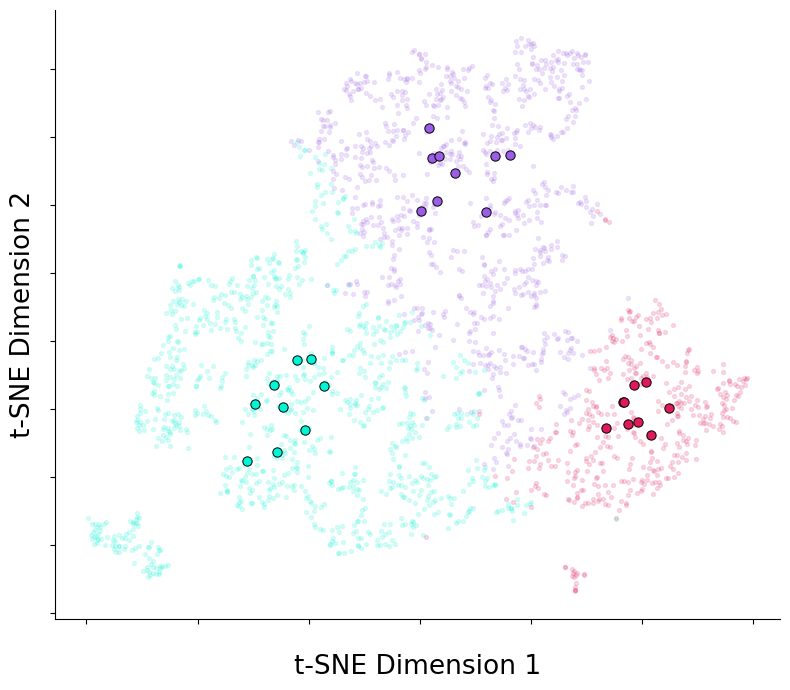

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_palette = {0: "#00F5D4", 1: "#9B5DE5", 2: "#DE1A58"} # Vivid Orange
plt.figure(figsize=(8,7))

# ---------------------------------------------------------
# 1) Plot ALL mitos (Background) - Color-coded by cluster
# ---------------------------------------------------------

for cl in cluster_palette.keys():
    # Filter background data for this specific cluster
    bg_sub = df_f[df_f["cluster"] == cl]
    
    plt.scatter(
        bg_sub["tsne_x"],
        bg_sub["tsne_y"],
        s=8,
        c=cluster_palette[cl], # Use the same palette
        alpha=0.15,            # Very low alpha makes it look like a "lighter version"
        label="_nolegend_"
    )

# ---------------------------------------------------------
# 2) Plot SELECTED mitos with BOLD COLORS (Foreground)
# ---------------------------------------------------------
for cl in tsne_master_df_3Cluster["cluster"].unique():
    sub = tsne_master_df_3Cluster[tsne_master_df_3Cluster["cluster"] == cl]

    plt.scatter(
        sub["tsne_x"],
        sub["tsne_y"],
        s=45,                  # Slightly increased size for better visibility
        c=cluster_palette[cl],
        edgecolor="black",
        linewidth=0.7,
        label=f"Cluster {cl}",
        zorder=3               # Ensures foreground stays on top
    )

# ----------------------------
# Plot Formatting
# ----------------------------
# plt.title("Highlighted Mitochondria on t-SNE", fontsize=20, pad=20)
plt.xlabel("t-SNE Dimension 1", fontsize=19, labelpad=22)
plt.ylabel("t-SNE Dimension 2", fontsize=19,labelpad=10)
plt.tick_params(axis='both', labelbottom=False, labelleft=False)
plt.xticks(fontsize=18, fontweight='bold')
plt.yticks(fontsize=18, fontweight='bold')
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig("Tsne_Cluster_Colored_Lighter_Background_FarApartMitos_5.png", dpi=300, bbox_inches="tight")
plt.show()


In [57]:

condition_order = [
    "No_Stimulation" , 
    "Glu(1min)", 
    "Glu(5min)", 
    "Glu(30min)", 
    "Glu+Ex-4(1min)", 
    "Glu+Ex-4(5min)", 
    "Glu+Ex-4(30min)", 
    "Ex-4(5min)", 
    "Ex-4(30min)"
]

# Your cell counts per condition
cell_counts = {
    "Ex-4(30min)": 4,
    "Ex-4(5min)": 3,
    "Glu(1min)": 4,
    "Glu(30min)": 8,
    "Glu(5min)": 8,
    "Glu+Ex-4(1min)": 4,
    "Glu+Ex-4(30min)": 8,
    "Glu+Ex-4(5min)": 8,
    "No_Stimulation": 8
}

def plot_condition_distribution(df):
    df = df.copy()
    df["condition"] = pd.Categorical(df["condition"], categories=condition_order, ordered=True)

    # ================================
    # 1. Raw counts
    # ================================
    count_table = (
        df.groupby(["cluster","condition"])
          .size()
          .unstack(fill_value=0)
          .reindex(columns=condition_order)
    )

    print("\n=== Raw Count Table ===\n")
    print(count_table)

    # ================================
    # 2. Row-wise % (existing)
    # ================================
    percent_table = count_table.div(count_table.sum(axis=1), axis=0) * 100

    # ================================
    # 3. NEW: Normalize counts by num_cells
    # ================================
    norm_table = count_table.copy()
    for cond in condition_order:
        norm_table[cond] = norm_table[cond] / cell_counts[cond]

    print("\n=== Normalized by Cell Count (Per-Cell Mito Count) ===\n")
    print(norm_table.round(2))

    # ================================
    # Heatmap: raw counts
    # ================================
    plt.figure(figsize=(8,5))
    sns.heatmap(count_table, annot=True, fmt="d", cmap="YlGnBu")
    plt.title("Raw Mito Counts (Cluster × Condition)")
    plt.tight_layout()
    plt.show()

    # ================================
    # Heatmap: row % 
    # ================================
    plt.figure(figsize=(9,5))
    sns.heatmap(percent_table, annot=True, fmt=".2f", cmap="OrRd")
    plt.title("Row-wise % Contribution (Cluster → Condition)")
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(11,4))

    ax = sns.heatmap(
        norm_table,
        annot=True,
        fmt=".2f",
        cmap="OrRd",
        annot_kws={"fontsize":14, "fontweight":"bold"},  # bold cell values
        cbar_kws={"shrink":0.8}
    )

    # 🔥 Bold title
    ax.set_title("Normalized Mitochondria Count", fontsize=22, pad=12)

    # ❌ Remove X-labels
    ax.set_xlabel("")
    ax.set_xticklabels([])

    # ✔ Bold Y-label
    ax.set_ylabel("Cluster", fontsize=20, labelpad = 48)

    # ✔ Bold Y-ticks
    ax.set_yticklabels([])

    # =====================================
    # 🔥 Make COLORBAR TICK NUMBERS larger + bold
    # =====================================
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=16)   # increase size

    # for tick in cbar.ax.get_yticklabels():
    #     tick.set_fontweight("bold")    # make bold

    plt.tight_layout()
    plt.savefig('Normalized_Mito_HeatMap_Long_2.png', dpi = 300, bbox_inches = 'tight')
    plt.show()




=== Raw Count Table ===

condition  No_Stimulation  Glu(1min)  Glu(5min)  Glu(30min)  Glu+Ex-4(1min)  \
cluster                                                                       
0                      92        102        166         149              58   
1                     171         51        105         176              51   
2                      68         32         66          91              16   

condition  Glu+Ex-4(5min)  Glu+Ex-4(30min)  Ex-4(5min)  Ex-4(30min)  
cluster                                                              
0                     171              199          29           38  
1                     116              145          21           16  
2                      50               88          10            7  

=== Normalized by Cell Count (Per-Cell Mito Count) ===

condition  No_Stimulation  Glu(1min)  Glu(5min)  Glu(30min)  Glu+Ex-4(1min)  \
cluster                                                                       
0            

/tmp/ipykernel_2275082/1419050787.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["cluster","condition"])


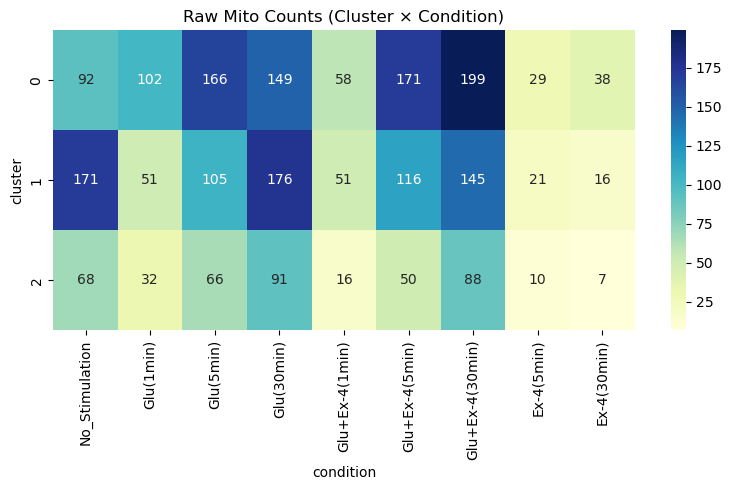

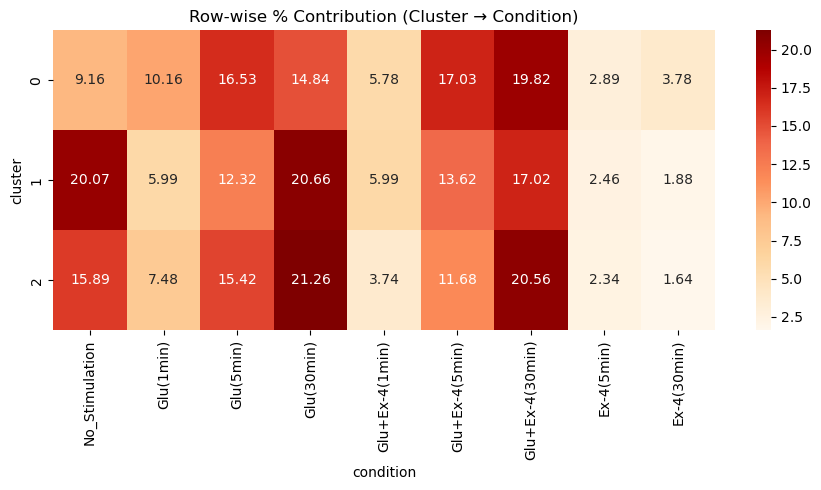

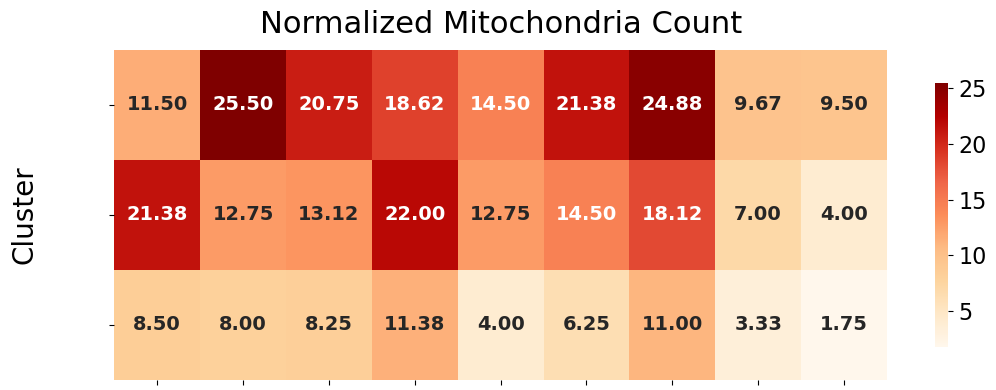

In [58]:
plot_condition_distribution(df_f)

🔴 Tortuosity Outliers Detected
Count: 196
Values:


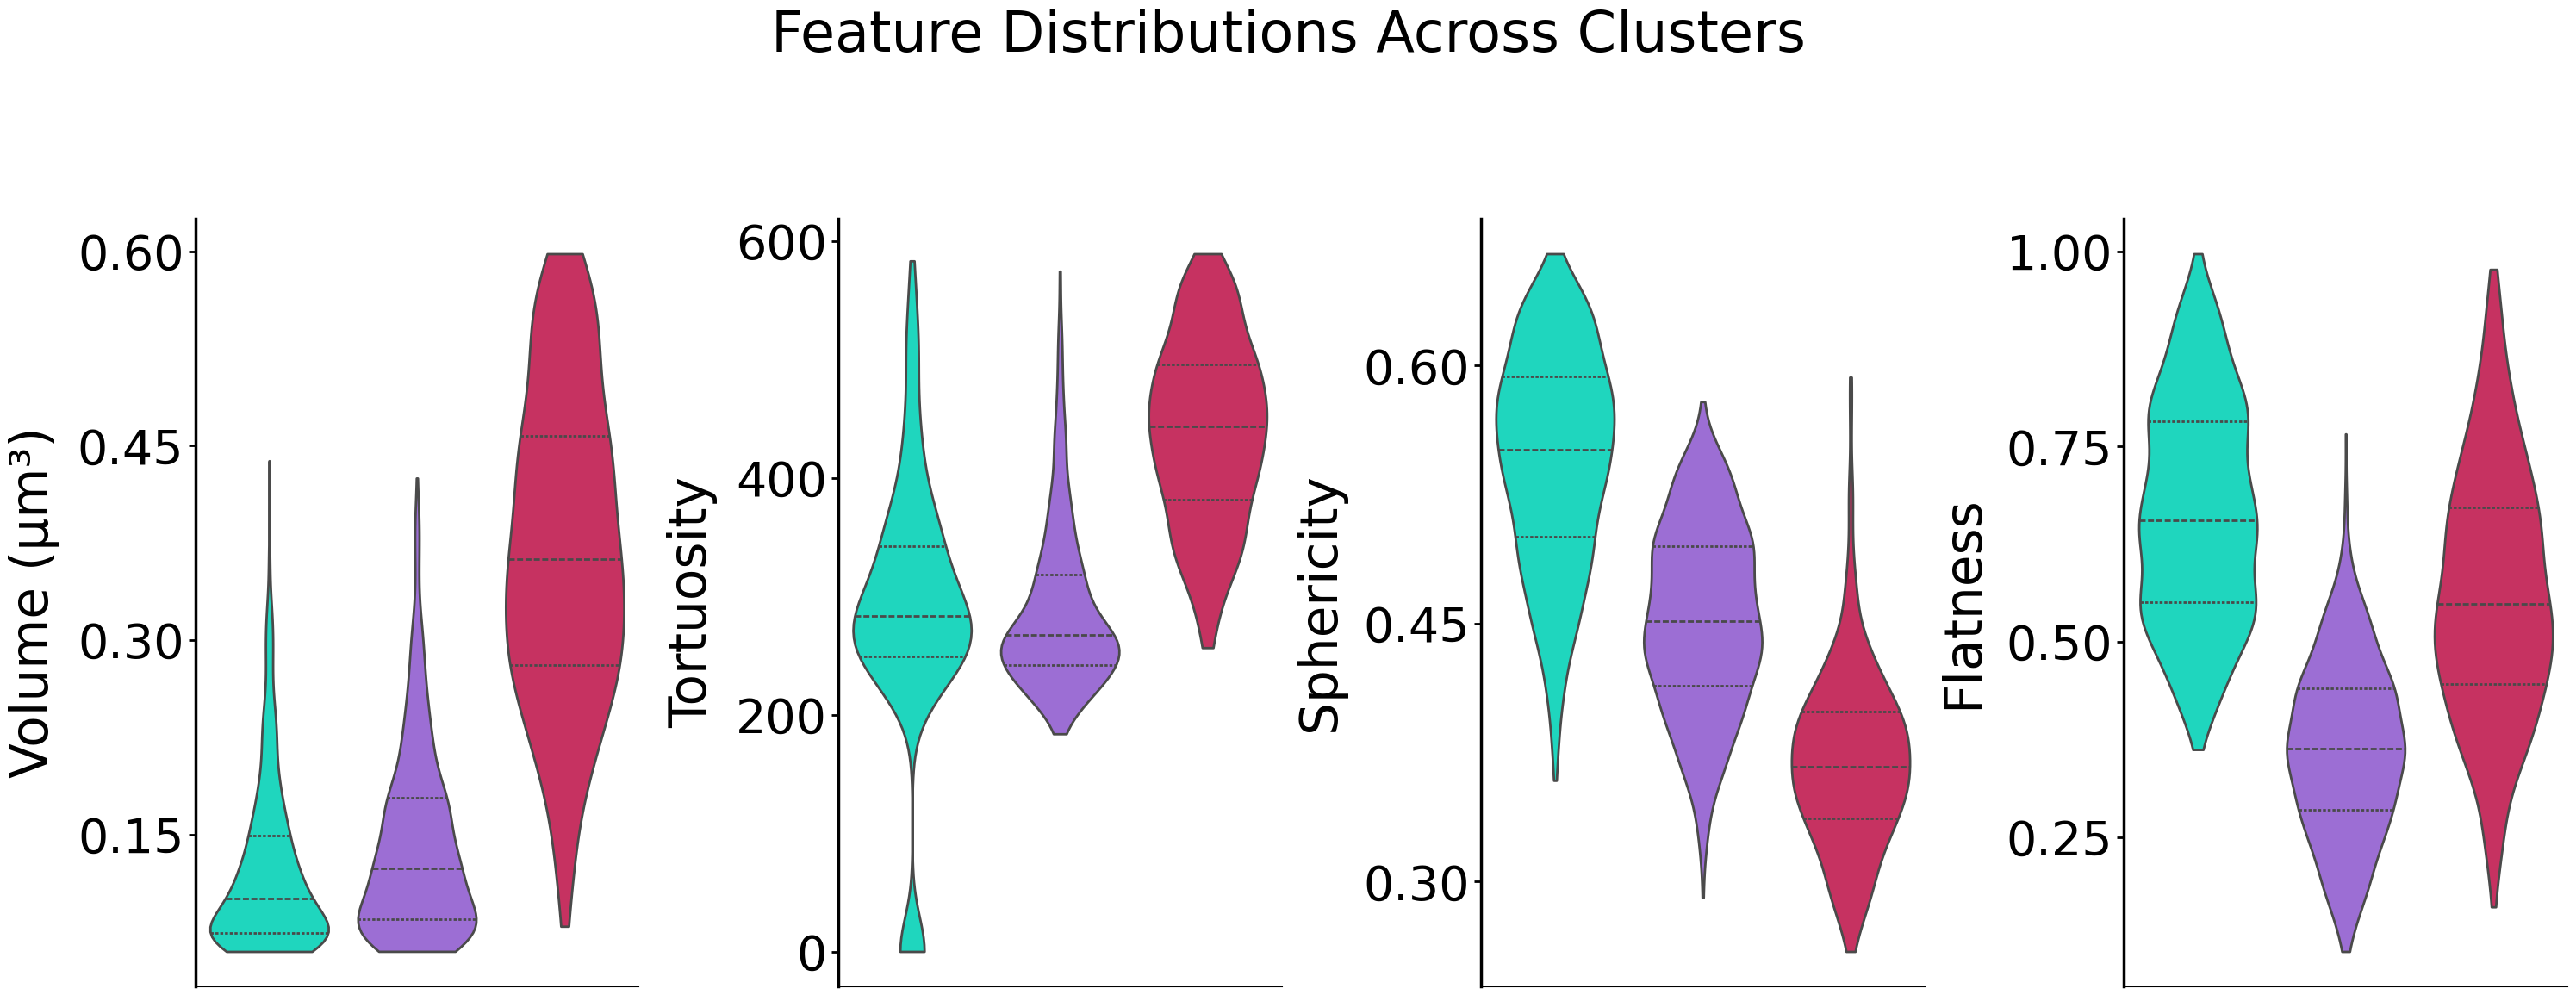

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.ticker as ticker

# Rename labels
feature_label_map = {
    "volume_um": "Volume (µm³)",
    "tortuosity": "Tortuosity",
    "sphericity": "Sphericity",
    "flatness": "Flatness"
}

cluster_name_map = {
    0: "Flat/Fragmented",
    1: "Tubular/Elongated",
    2: "Curved/Branched",
    # 3: "Fragmented"
}

cluster_palette = {"0": "#00F5D4", "1": "#9B5DE5", "2": "#DE1A58"} # Vivid Orange

features = list(feature_label_map.keys())
df_raw = df_f.copy()

# Melt
df_long = df_raw.melt(
    id_vars=["condition", "cluster"],
    value_vars=features,
    var_name="feature",
    value_name="value"
)

# 🔑 Ensure cluster is categorical string
df_long["cluster"] = df_long["cluster"].astype(str)
df_long["feature"] = df_long["feature"].map(feature_label_map)


# -----------------------------
# OUTLIER DETECTION (TORTUOSITY)
# -----------------------------
tort_df = df_long[df_long["feature"] == "Tortuosity"].copy()

Q1 = tort_df["value"].quantile(0.25)
Q3 = tort_df["value"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = tort_df[
    (tort_df["value"] < lower) | (tort_df["value"] > upper)
]

print("🔴 Tortuosity Outliers Detected")
print(f"Count: {len(outliers)}")
print("Values:")
# print(outliers["value"].sort_values().to_list())

# Remove outliers ONLY for plotting
df_long_clean = df_long[
    ~(
        (df_long["feature"] == "Tortuosity") &
        (df_long["value"] > upper)
    )
]


# ------------------------------------------------------
# SUBPLOTS
# ------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(30, 10))
cluster_order = ["0", "1", "2"]   # fixed order


for ax, feature in zip(axes, feature_label_map.values()):

    df_fea = df_long_clean[df_long_clean["feature"] == feature]

    sns.violinplot(
        data=df_fea,
        x="cluster",
        y="value",
        hue="cluster",
        order=cluster_order,
        hue_order=cluster_order,
        palette=cluster_palette,
        dodge=False,
        inner="quartile",
        linewidth=2,
        cut=0,
        ax=ax
    )

    # Remove legend
    if ax.legend_ is not None:
        ax.legend_.remove()

    # ❌ Completely remove x-axis ticks, labels, and spine
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.tick_params(axis="x", bottom=False)
    ax.spines["bottom"].set_visible(False)

    # ✅ Put feature name on Y-axis
    ax.set_ylabel(feature, fontsize=43, labelpad=15)

    ax.tick_params(axis="y", labelsize=40, width=2, length=6)
 
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    # Spines
    ax.spines["left"].set_linewidth(2.5)
    ax.spines["left"].set_color("black")
    sns.despine(ax=ax, top=True, right=True)

# ------------------------------------------------------
# TITLE
# ------------------------------------------------------
fig.suptitle(
    "Feature Distributions Across Clusters",
    fontsize=47,
    y=1.15)

plt.tight_layout()
plt.savefig(
    "Feature_ViolinPlot_Selected_Features_NoOutliers_2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
